# 01 — Exploratory Data Analysis

A first look at `cmi_internet.csv` before any modelling: how severe internet
use is distributed, who the participants are, how much data is missing, and
which features move together.

Nothing here changes the data — this notebook only reads and plots.

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PATHS

raw_dataset = pd.read_csv(PATHS["raw_data"])
print(f"Loaded {raw_dataset.shape[0]} participants, "
      f"{raw_dataset.shape[1]} columns")

Loaded 8460 participants, 82 columns


In [2]:
# One consistent look for every plot in this notebook.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

/var/folders/0k/hc44cb1d4x59cxg7nn73qt7m0000gn/T/ipykernel_48260/2156133319.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sii", data=raw_dataset, ax=ax[1], palette="viridis")


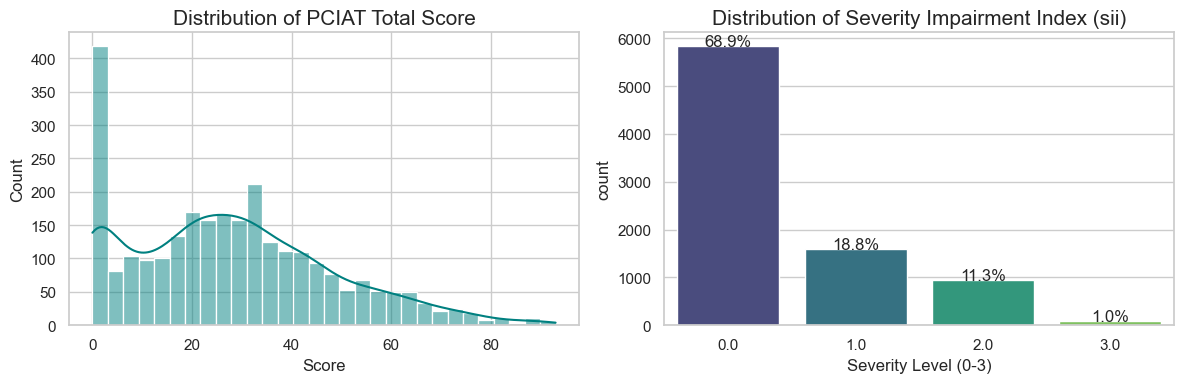

In [3]:
# The target and the score it comes from.
# PCIAT_Total is the raw questionnaire score (0-100); sii buckets it into four
# severity levels. The class counts show how imbalanced the problem is.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(raw_dataset["PCIAT-PCIAT_Total"].dropna(), bins=30, kde=True,
             ax=ax[0], color="teal")
ax[0].set_title("Distribution of PCIAT Total Score", fontsize=15)
ax[0].set_xlabel("Score")

sns.countplot(x="sii", data=raw_dataset, ax=ax[1], palette="viridis")
labelled_total = len(raw_dataset["sii"].dropna())
for bar in ax[1].patches:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width() / 2., height + 3,
               "{:1.1f}%".format(100 * height / labelled_total), ha="center")
ax[1].set_title("Distribution of Severity Impairment Index (sii)", fontsize=15)
ax[1].set_xlabel("Severity Level (0-3)")

plt.tight_layout()
plt.show()

/var/folders/0k/hc44cb1d4x59cxg7nn73qt7m0000gn/T/ipykernel_48260/2187917714.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sii_label", y="SDS-SDS_Total_Raw", data=raw_dataset,


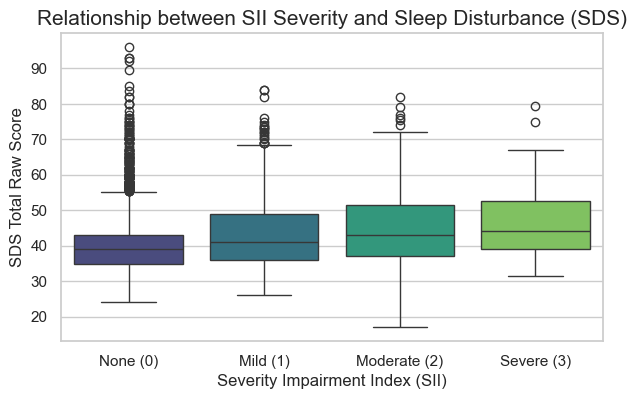

In [4]:
# Sleep disturbance against severity. This turns out to be the single
# strongest signal in the dataset, and every explainability method later in
# the project points back at it.
sii_labels = {0: "None (0)", 1: "Mild (1)", 2: "Moderate (2)", 3: "Severe (3)"}
raw_dataset["sii_label"] = raw_dataset["sii"].map(sii_labels)

plt.figure(figsize=(7, 4))
sns.boxplot(x="sii_label", y="SDS-SDS_Total_Raw", data=raw_dataset,
            order=list(sii_labels.values()), palette="viridis")
plt.title("Relationship between SII Severity and Sleep Disturbance (SDS)",
          fontsize=15)
plt.xlabel("Severity Impairment Index (SII)")
plt.ylabel("SDS Total Raw Score")
plt.show()

/var/folders/0k/hc44cb1d4x59cxg7nn73qt7m0000gn/T/ipykernel_48260/2090410700.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x="Basic_Demos-Age", y="PCIAT-PCIAT_Total", data=raw_dataset,


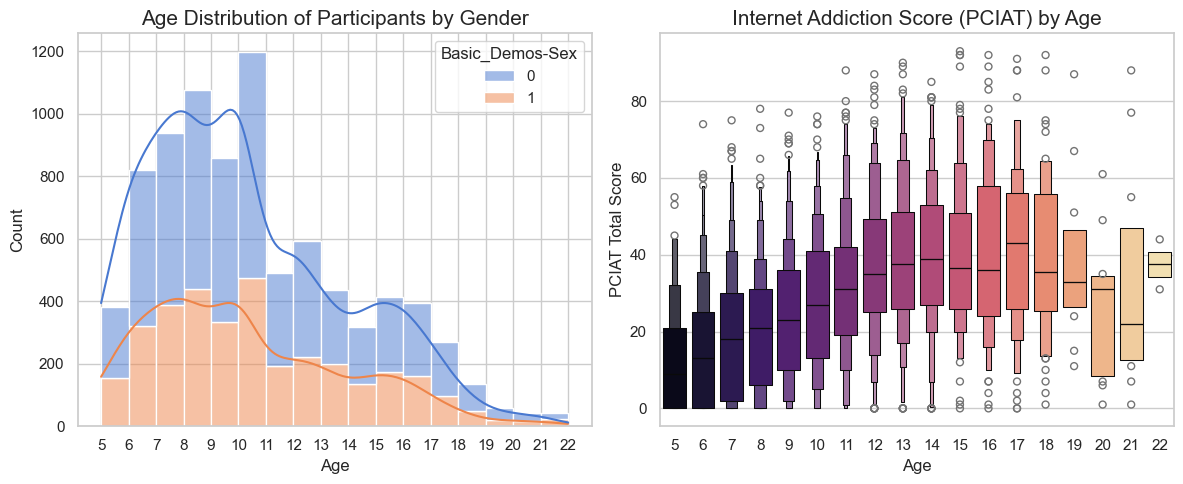

In [5]:
# Who is in the study, and does severity track with age?
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

age = raw_dataset["Basic_Demos-Age"]
sns.histplot(data=raw_dataset, x="Basic_Demos-Age", hue="Basic_Demos-Sex",
             multiple="stack", bins=int(age.max() - age.min()), kde=True,
             ax=ax[0])
ax[0].set_title("Age Distribution of Participants by Gender", fontsize=15)
ax[0].set_xticks(range(int(age.min()), int(age.max()) + 1))
ax[0].set_xlabel("Age")

# Boxen (letter-value) plot rather than a boxplot: it shows the tails of each
# age group, which matter here because severe cases are rare.
sns.boxenplot(x="Basic_Demos-Age", y="PCIAT-PCIAT_Total", data=raw_dataset,
              palette="magma", ax=ax[1])
ax[1].set_title("Internet Addiction Score (PCIAT) by Age", fontsize=15)
ax[1].set_xlabel("Age")
ax[1].set_ylabel("PCIAT Total Score")

plt.tight_layout()
plt.show()

/var/folders/0k/hc44cb1d4x59cxg7nn73qt7m0000gn/T/ipykernel_48260/1101789681.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x="sii", y="Physical-BMI", data=raw_dataset, palette="coolwarm",
/var/folders/0k/hc44cb1d4x59cxg7nn73qt7m0000gn/T/ipykernel_48260/1101789681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sii", y="Physical-Waist_Circumference", data=raw_dataset,


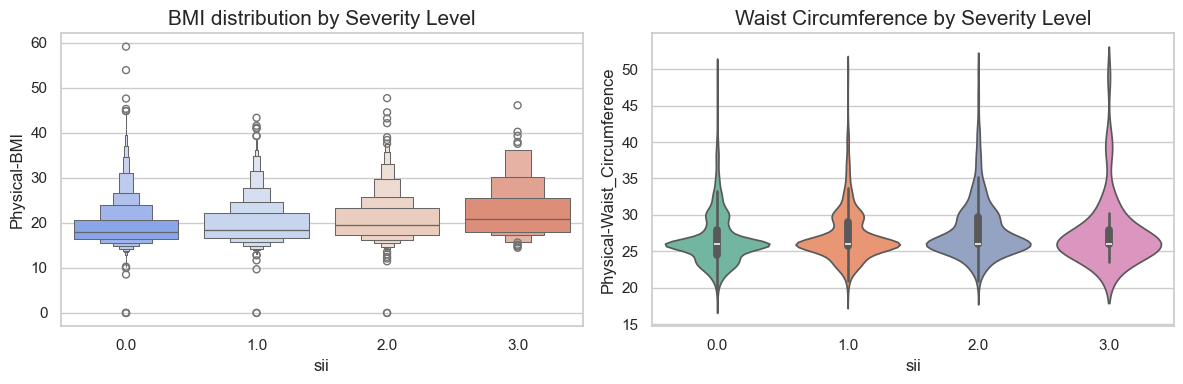

In [6]:
# Do body-composition measurements separate the severity levels?
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxenplot(x="sii", y="Physical-BMI", data=raw_dataset, palette="coolwarm",
              ax=ax[0])
ax[0].set_title("BMI distribution by Severity Level", fontsize=15)

sns.violinplot(x="sii", y="Physical-Waist_Circumference", data=raw_dataset,
               palette="Set2", ax=ax[1])
ax[1].set_title("Waist Circumference by Severity Level", fontsize=15)

plt.tight_layout()
plt.show()

/var/folders/0k/hc44cb1d4x59cxg7nn73qt7m0000gn/T/ipykernel_48260/1615705020.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent[:30], y=missing_percent[:30].index,


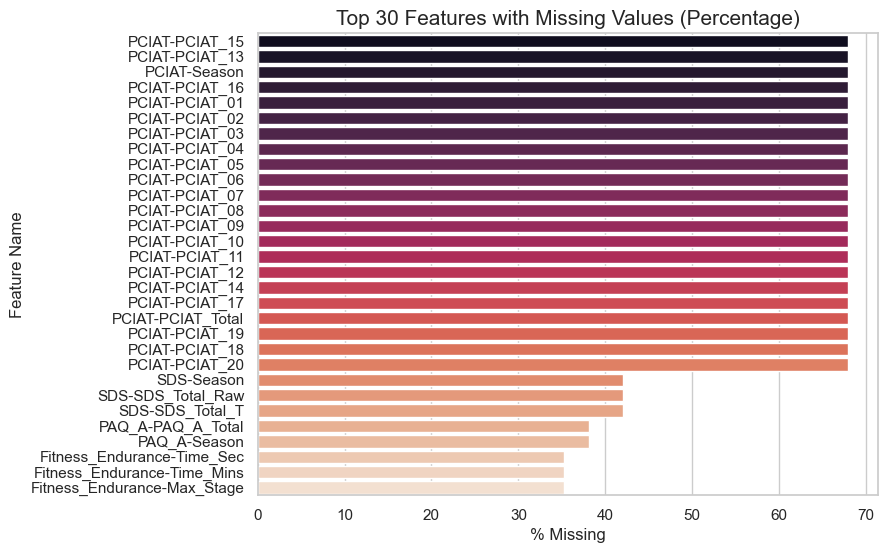

In [7]:
# Missing data is the dominant practical problem in this dataset: several
# features are absent for most participants, which drives the imputation work
# in notebook 02.
missing_percent = raw_dataset.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=missing_percent[:30], y=missing_percent[:30].index,
            palette="rocket")
plt.title("Top 30 Features with Missing Values (Percentage)", fontsize=15)
plt.xlabel("% Missing")
plt.ylabel("Feature Name")
plt.show()

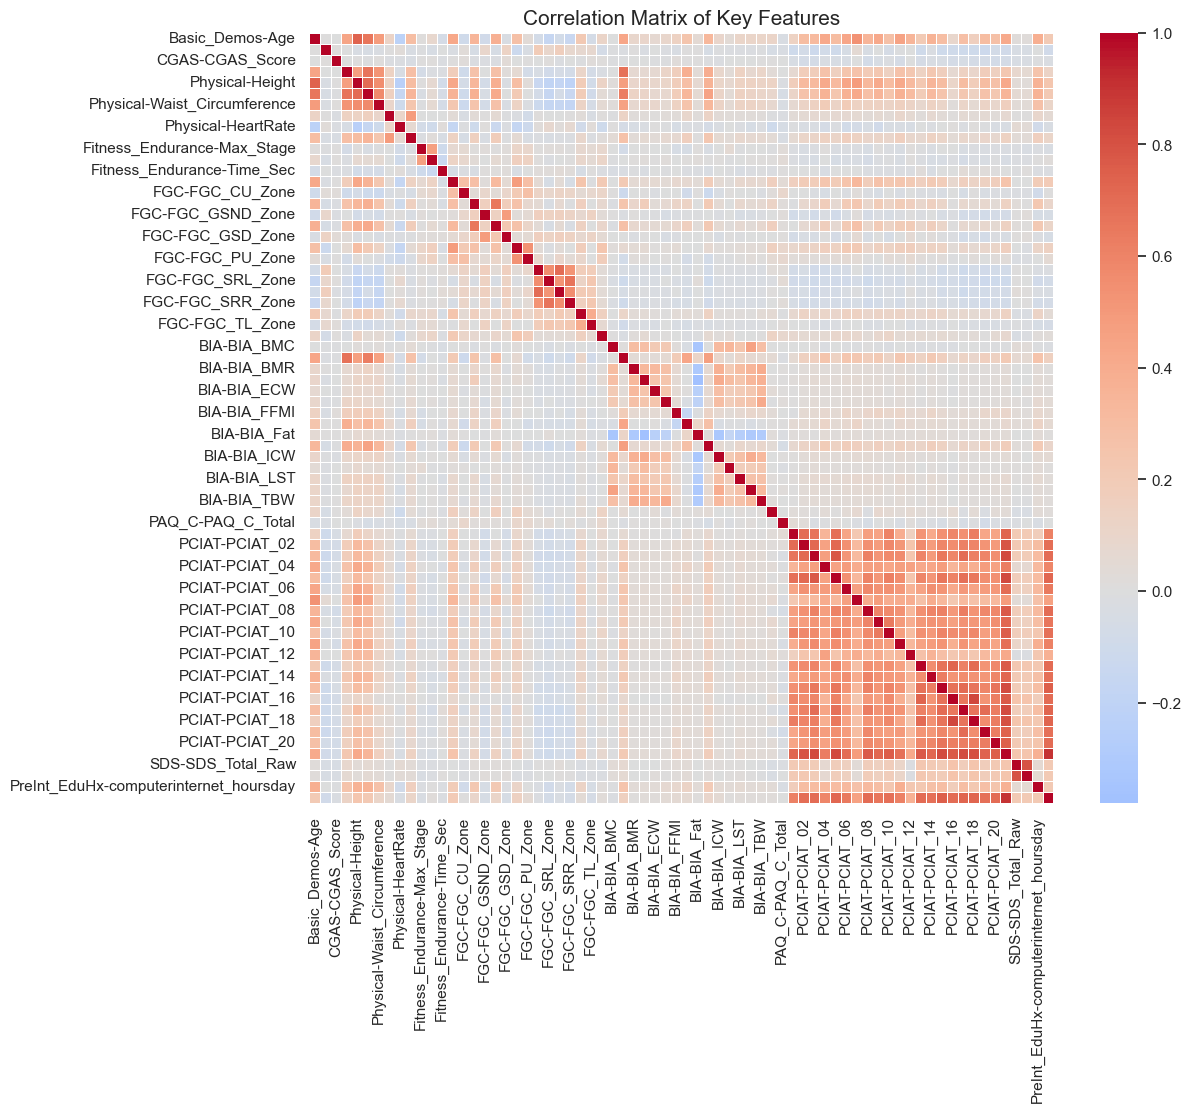

In [8]:
# Correlation structure across the main features.
# The bright block in the PCIAT rows is the leakage this project has to remove:
# those 20 items are what sii is computed from, so any model that keeps them
# scores near-perfectly without learning anything useful.
columns_of_interest = (
    ["Basic_Demos-Age", "Basic_Demos-Sex", "CGAS-CGAS_Score", "Physical-BMI",
     "Physical-Height", "Physical-Weight", "Physical-Waist_Circumference",
     "Physical-Diastolic_BP", "Physical-HeartRate", "Physical-Systolic_BP",
     "Fitness_Endurance-Max_Stage", "Fitness_Endurance-Time_Mins",
     "Fitness_Endurance-Time_Sec"]
    + [f"FGC-FGC_{name}" for name in
       ["CU", "CU_Zone", "GSND", "GSND_Zone", "GSD", "GSD_Zone", "PU",
        "PU_Zone", "SRL", "SRL_Zone", "SRR", "SRR_Zone", "TL", "TL_Zone"]]
    + [f"BIA-BIA_{name}" for name in
       ["Activity_Level_num", "BMC", "BMI", "BMR", "DEE", "ECW", "FFM", "FFMI",
        "FMI", "Fat", "Frame_num", "ICW", "LDM", "LST", "SMM", "TBW"]]
    + ["PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total"]
    + [f"PCIAT-PCIAT_{i:02d}" for i in range(1, 21)]
    + ["PCIAT-PCIAT_Total", "SDS-SDS_Total_Raw", "SDS-SDS_Total_T",
       "PreInt_EduHx-computerinternet_hoursday", "sii"]
)

plt.figure(figsize=(12, 10))
sns.heatmap(raw_dataset[columns_of_interest].corr(), cmap="coolwarm", center=0,
            linewidths=0.5)
plt.title("Correlation Matrix of Key Features", fontsize=15)
plt.show()